# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `[Phumnawat Phosawatmanee]`  
**SFU ID:** `[301540883]`  
**Date:** `[6/29/2026]`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [4]:
df_ab = pd.read_csv('phigma_ab_study.csv')

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                 object
ab_group                                object
device_type                             object
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                             object
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NaN,5,1,1,0,38,17.91


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,1323,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,U79488,control,desktop,NaN,NaN,EU,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,593,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [6]:
# Missing values
df_ab.isnull().sum()


,0
user_id,0
ab_group,0
device_type,0
account_age_days,0
prior_whiteboard_sessions,0
plan_region,677
num_collaborators,0
feature_tour_completed,0
templates_used,0
ai_suggestions_used,0


### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


In [ ]:
BEGIN
    Load target outcome variable

    // 1. Normality & Transformation Visualizations
    Initialize three-panel visual layout

    Draw histogram of raw outcome distribution
    Transform outcome variable using natural logarithm
    Draw histogram of log-transformed outcome distribution
    Draw Q-Q plot comparing log-transformed distribution to a normal distribution

    Render visualizations

    // 2. Statistical Diagnostics
    Compute and output skewness for both raw and log-transformed distributions
END

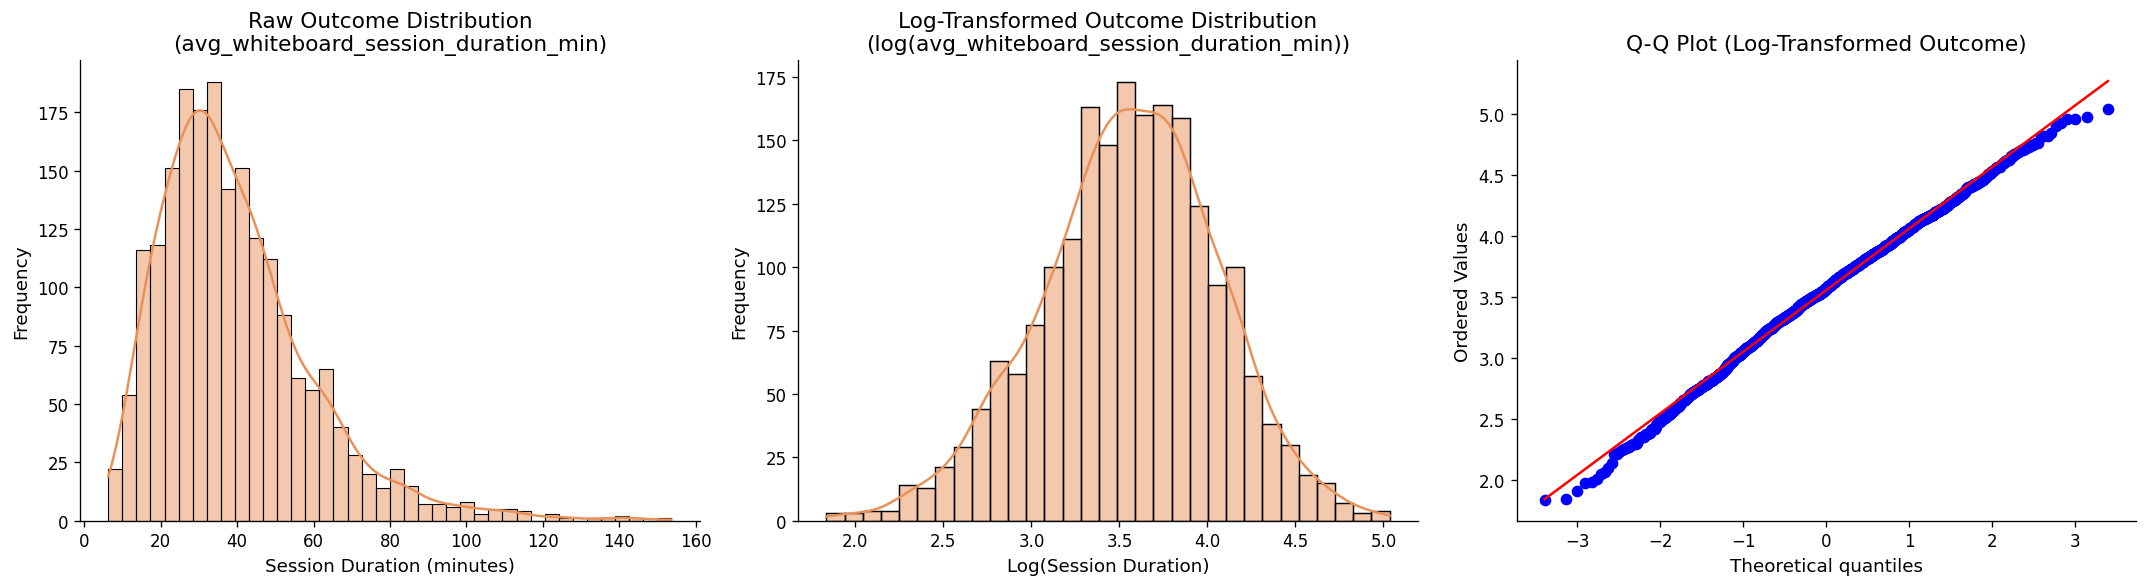

Skewness of raw outcome:      1.377
Skewness of log outcome:      -0.213


In [7]:
# A1.1 — Outcome distribution

# BEGIN
# Load target outcome variable
outcome = df_ab['avg_whiteboard_session_duration_min']

# 1. Normality & Transformation Visualizations
# Initialize three-panel visual layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Draw histogram of raw outcome distribution
sns.histplot(outcome, kde=True, ax=axes[0], color=ACCENT)
axes[0].set_title('Raw Outcome Distribution\n(avg_whiteboard_session_duration_min)')
axes[0].set_xlabel('Session Duration (minutes)')
axes[0].set_ylabel('Frequency')

# Transform outcome variable using natural logarithm
outcome_log = np.log(outcome)

# Draw histogram of log-transformed outcome distribution
sns.histplot(outcome_log, kde=True, ax=axes[1], color=ACCENT)
axes[1].set_title('Log-Transformed Outcome Distribution\n(log(avg_whiteboard_session_duration_min))')
axes[1].set_xlabel('Log(Session Duration)')
axes[1].set_ylabel('Frequency')

# Draw Q-Q plot comparing log-transformed distribution to a normal distribution
stats.probplot(outcome_log, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Log-Transformed Outcome)')

# Render visualizations
plt.tight_layout()
plt.show()

# 2. Statistical Diagnostics
# Compute and output skewness for both raw and log-transformed distributions
print("Skewness of raw outcome:     ", round(outcome.skew(), 3))
print("Skewness of log outcome:     ", round(outcome_log.skew(), 3))
# END

✏️ My interpretation (A1.1):

The raw average whiteboard session duration is right-skewed (skewness = 1.377) — most sessions are short, but a handful of users have very long sessions that drag out a long tail on the right side. Once I apply a natural log transformation, the distribution looks much closer to normal (skewness drops to -0.213), and the Q-Q plot supports this too, following the straight line pretty closely with just minor deviations at the tails. Because of this, I'll go with the log-transformed outcome variable for my linear regression model, since it satisfies the normality assumption a lot better than the raw data does.

#### A1.2 — Examine the confounders

In [ ]:
// Define the analytical pipeline
BEGIN
    Load AB testing dataset

    // 1. Visual Exploratory Data Analysis
    Initialize side-by-side visualization layouts

    Draw boxplot comparison of AI suggestion usage across experimental groups
    Draw scatter plot comparing whiteboard activity density against session durations

    Optimize layout and display visualizations

    // 2. Statistical Analysis
    Calculate and print the correlation between whiteboard activity and session duration
    Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
END

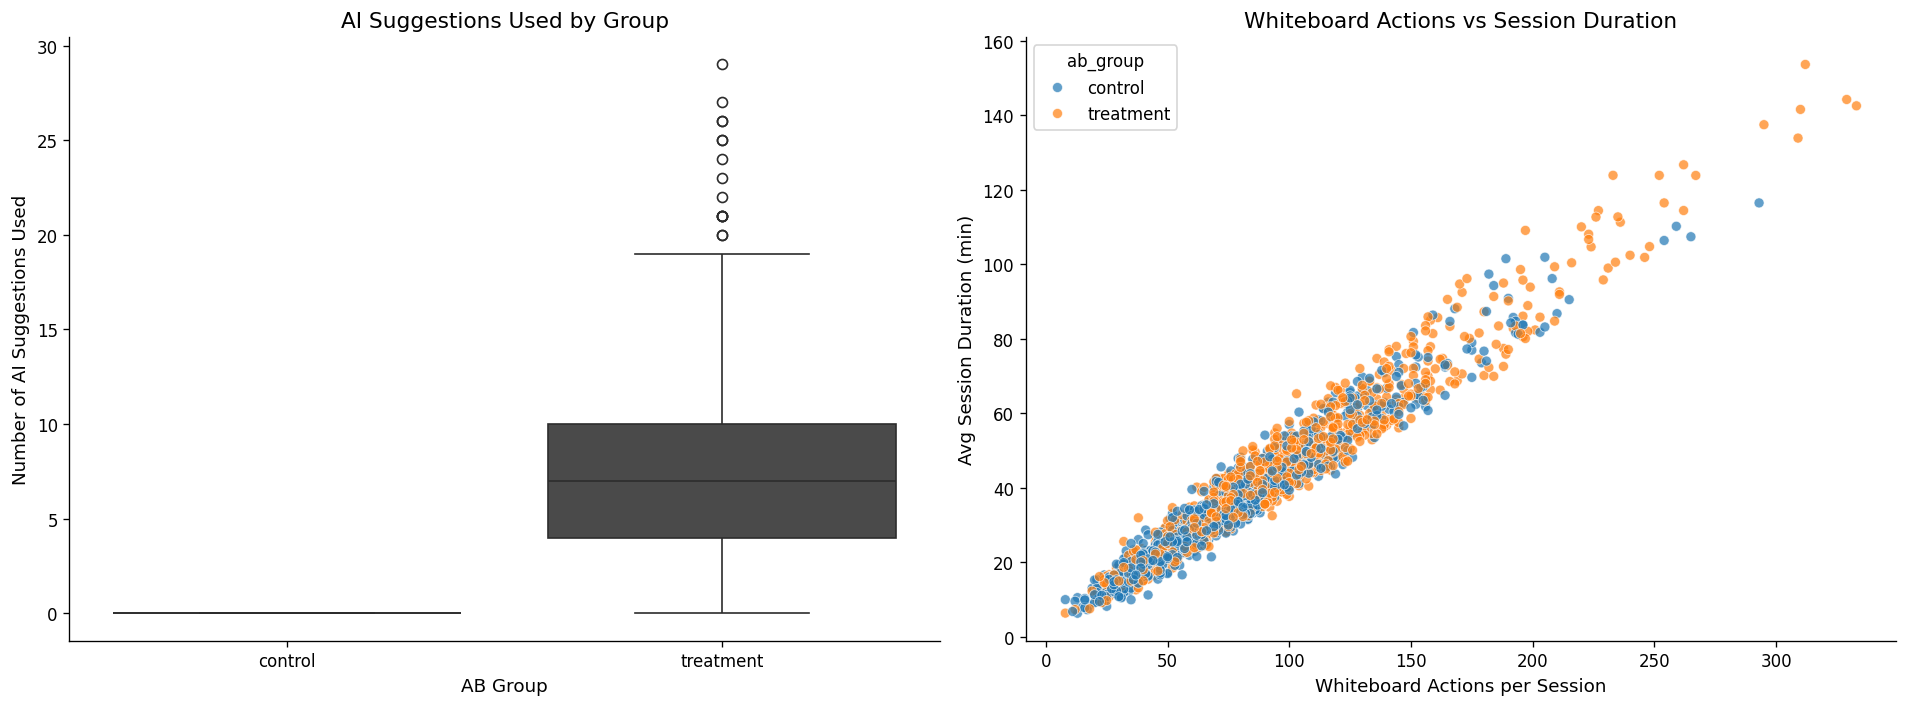

Correlation between whiteboard actions per session and session duration: 0.974

Descriptive statistics of AI suggestions used by group:
            count      mean       std  min  25%  50%   75%   max
ab_group                                                        
control    1011.0  0.000000  0.000000  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.334681  4.550684  0.0  4.0  7.0  10.0  29.0


In [9]:
# A1.2 — Examine the confounders

# BEGIN
# Load AB testing dataset (already loaded as df_ab)

# 1. Visual Exploratory Data Analysis
# Initialize side-by-side visualization layouts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Draw boxplot comparison of AI suggestion usage across experimental groups
sns.boxplot(data=df_ab, x='ab_group', y='ai_suggestions_used', ax=axes[0], palette=[ACCENT, '#4a4a4a'])
axes[0].set_title('AI Suggestions Used by Group')
axes[0].set_xlabel('AB Group')
axes[0].set_ylabel('Number of AI Suggestions Used')

# Draw scatter plot comparing whiteboard activity density against session durations
sns.scatterplot(data=df_ab, x='whiteboard_actions_per_session',
                y='avg_whiteboard_session_duration_min',
                hue='ab_group', alpha=0.7, ax=axes[1])
axes[1].set_title('Whiteboard Actions vs Session Duration')
axes[1].set_xlabel('Whiteboard Actions per Session')
axes[1].set_ylabel('Avg Session Duration (min)')

# Optimize layout and display visualizations
plt.tight_layout()
plt.show()

# 2. Statistical Analysis
# Calculate and print the correlation between whiteboard activity and session duration
correlation = df_ab['whiteboard_actions_per_session'].corr(df_ab['avg_whiteboard_session_duration_min'])
print(f"Correlation between whiteboard actions per session and session duration: {round(correlation, 3)}")

# Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
print("\nDescriptive statistics of AI suggestions used by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe())
# END

**✏️ Your interpretation (A1.2):**

I see that in the treatment group, users used many more AI suggestions (mean = 7.33) while the control group used almost zero. This is expected because only the treatment group has access to AI.
I also see a very strong positive correlation (0.974) between whiteboard_actions_per_session and session duration. It means that users who do more actions per session usually stay much longer.
I think neither variable should be included in the model. ai_suggestions_used is directly affected by the treatment, and whiteboard_actions_per_session is highly related to the outcome itself. Including them would create bias in the results.


#### A1.3 — Predictor distributions and relationships with outcome

In [ ]:
BEGIN
    Define list of numerical predictor variables
    Compute log-transformed outcome variable

    Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)

    FOR each predictor variable:
        // Top row: Univariate Analysis
        Draw histogram to show distribution of the predictor

        // Bottom row: Bivariate Analysis
        Draw scatter plot comparing predictor against log-transformed outcome
        Calculate correlation coefficient between predictor and log-transformed outcome
        Annotate plot with correlation coefficient
    END FOR

    Add global title and render layout
END

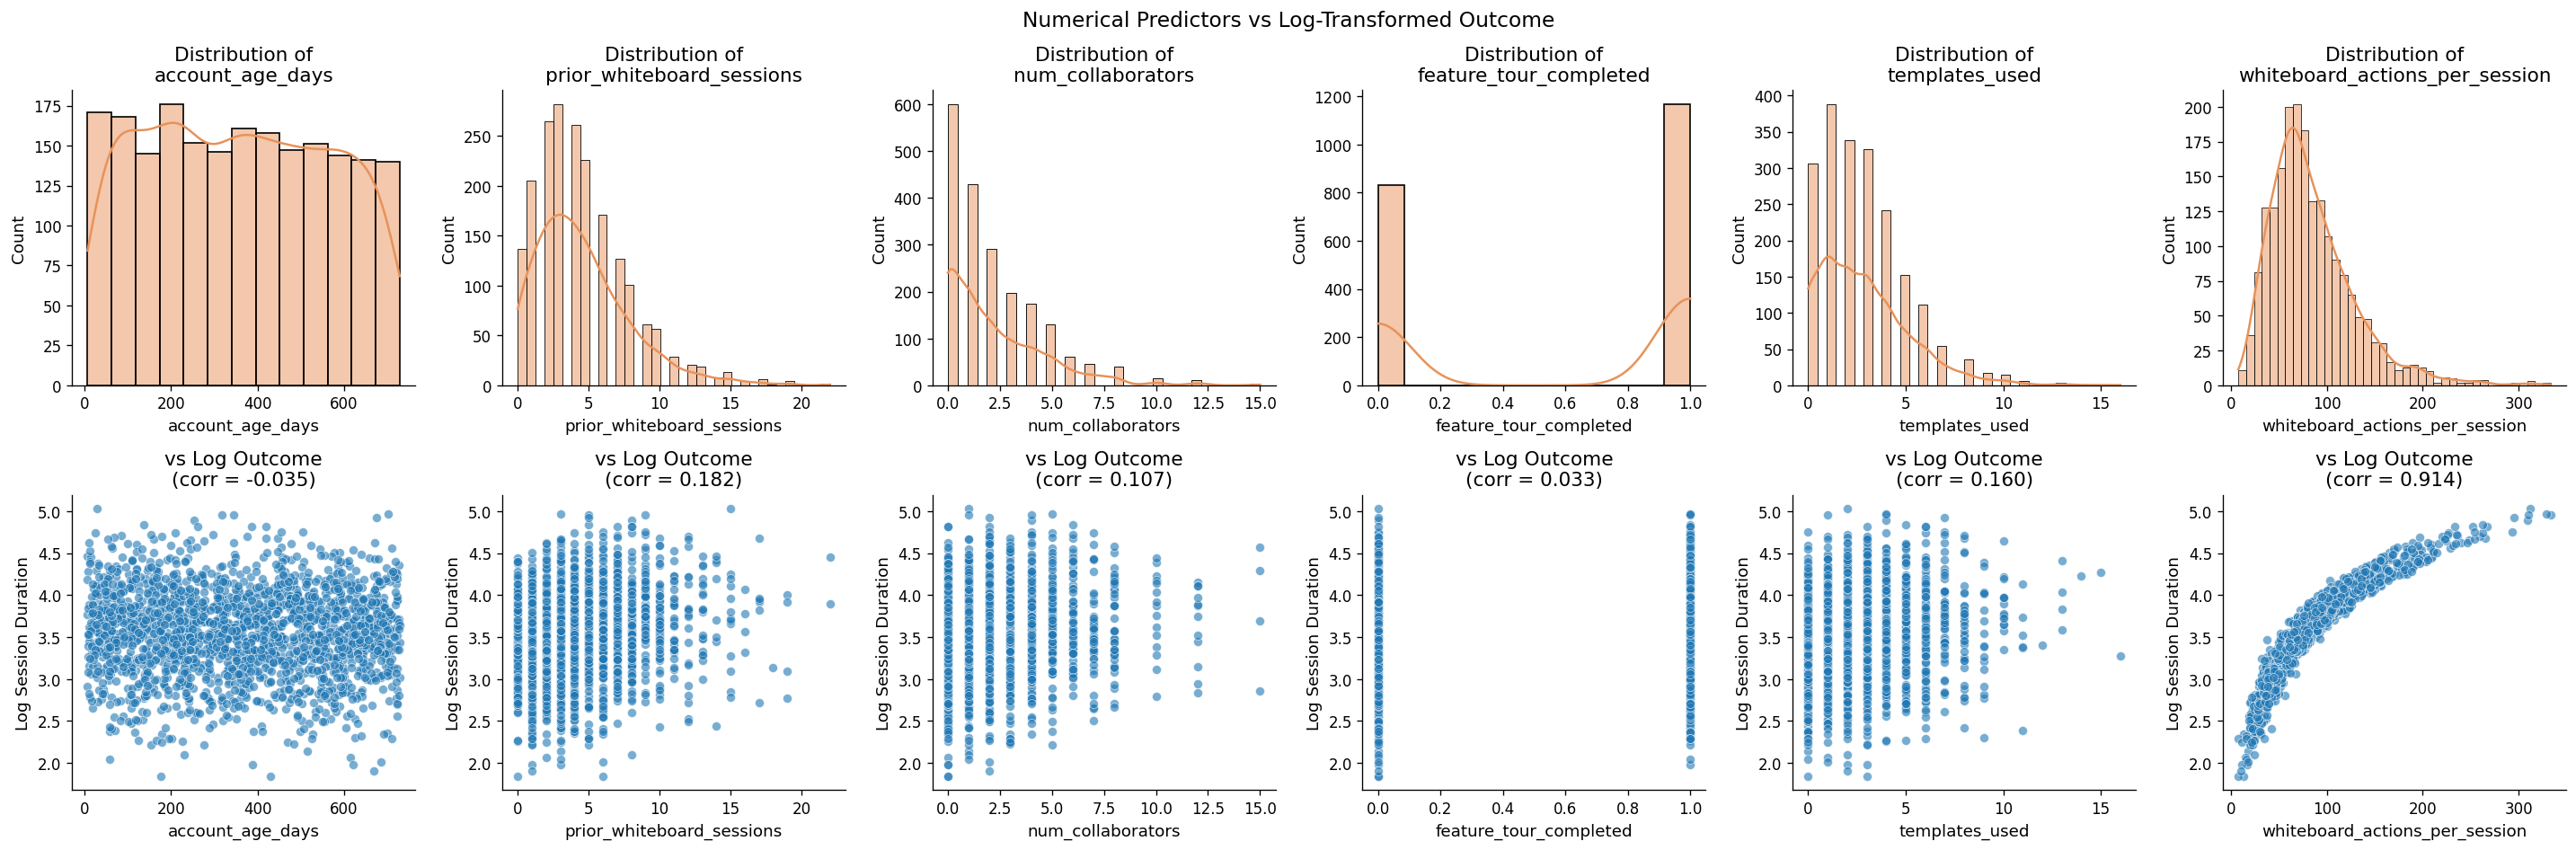

In [10]:
# A1.3 — Predictor distributions and relationships with outcome (Numerical)

# BEGIN
# Define list of numerical predictor variables
num_predictors = ['account_age_days', 'prior_whiteboard_sessions', 'num_collaborators',
                  'feature_tour_completed', 'templates_used', 'whiteboard_actions_per_session']

# Compute log-transformed outcome variable
df_ab['log_outcome'] = np.log(df_ab['avg_whiteboard_session_duration_min'])

# Initialize visual grid layout (2 rows by N columns)
n = len(num_predictors)
fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

for i, predictor in enumerate(num_predictors):
    # Top row: Univariate Analysis - Histogram
    sns.histplot(data=df_ab, x=predictor, kde=True, ax=axes[0, i], color=ACCENT)
    axes[0, i].set_title(f'Distribution of\n{predictor}')

    # Bottom row: Bivariate Analysis - Scatter plot
    sns.scatterplot(data=df_ab, x=predictor, y='log_outcome', ax=axes[1, i], alpha=0.6)
    corr = df_ab[predictor].corr(df_ab['log_outcome'])
    axes[1, i].set_title(f'vs Log Outcome\n(corr = {corr:.3f})')
    axes[1, i].set_ylabel('Log Session Duration')

# Add global title and render layout
fig.suptitle('Numerical Predictors vs Log-Transformed Outcome', fontsize=14)
plt.tight_layout()
plt.show()
# END

In [ ]:
BEGIN
    Define list of categorical predictor variables
    Initialize visual grid layout (1 row by N columns, where N is the number of categories)

    FOR each categorical variable:
        Retrieve unique category levels

        Group log-transformed outcome values by category levels

        Draw boxplots of log-transformed outcome grouped by category level
        Rotate category axis labels for readability

        Label axis and set titles
    END FOR

    Render layout
END

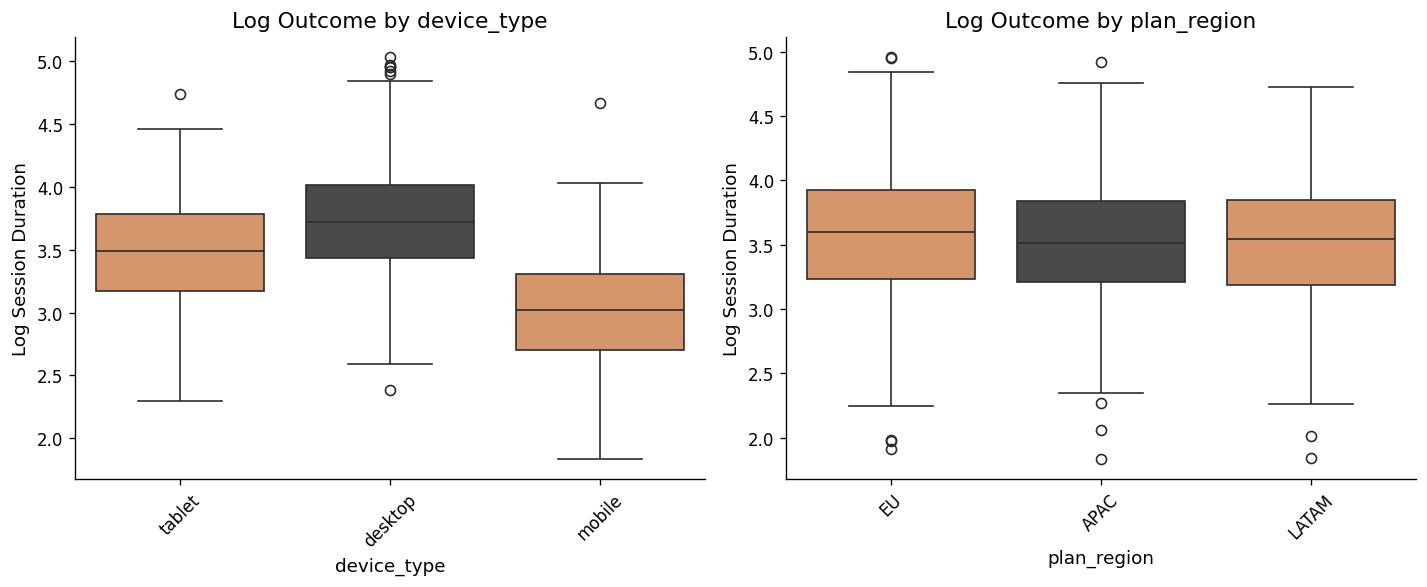

In [11]:
# A1.3 — Predictor distributions and relationships with outcome (Categorical)

# BEGIN
# Define list of categorical predictor variables
cat_predictors = ['device_type', 'plan_region']

# Initialize visual grid layout
n = len(cat_predictors)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))

for i, predictor in enumerate(cat_predictors):
    # Retrieve unique category levels
    # Group log-transformed outcome by category levels
    sns.boxplot(data=df_ab, x=predictor, y='log_outcome', ax=axes[i], palette=[ACCENT, '#4a4a4a'])

    # Rotate category axis labels for readability
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'Log Outcome by {predictor}')
    axes[i].set_ylabel('Log Session Duration')

# Render layout
plt.tight_layout()
plt.show()
# END

**✏️ Your interpretation (A1.3):**

From the plots, I see that whiteboard_actions_per_session has the strongest positive correlation (0.914) with the log outcome, so it looks the most promising. Other predictors like prior_whiteboard_sessions and templates_used show weak positive relationships. Some variables such as prior_whiteboard_sessions, num_collaborators and templates_used are right-skewed.
I am excluding ai_suggestions_used and whiteboard_actions_per_session from the model. The first one is directly influenced by the treatment, and the second one is almost part of the outcome, which can cause endogeneity problem.


### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [ ]:
BEGIN
    Load baseline dataset

    // 1. Encode Categorical Variables
    Convert experimental group ('ab_group') into a binary integer indicator
    Generate dummy indicators (one-hot encoding) for device types, omitting the first category
    Generate dummy indicators (one-hot encoding) for regions, omitting the first category

    // 2. Perform Optional Transformations
    Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values

    // 3. Assemble Modeling Dataset
    Merge numerical characteristics, binary groups, and dummy indicators into matrix X
    Set target vector y as the log-transformed outcome variable

    // 4. Quality Control
    Verify that there are no missing (null) values in feature matrix X
    Inspect matrix dimensions and print a preview of the processed data
END

In [12]:
# A2 — Feature Engineering

# BEGIN
# Load baseline dataset (already loaded as df_ab)

# 1. Encode Categorical Variables
# Convert experimental group into binary integer indicator
df_ab['treatment'] = (df_ab['ab_group'] == 'treatment').astype(int)

# Generate dummy indicators for device types, omitting the first category
device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device', drop_first=True).astype(int)

# Generate dummy indicators for regions, omitting the first category
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='region', drop_first=True).astype(int)

# 2. Perform Optional Transformations
# Log-transform right-skewed numerical predictors using log(x + 1)
df_ab['log_prior_whiteboard_sessions'] = np.log1p(df_ab['prior_whiteboard_sessions'])
df_ab['log_num_collaborators'] = np.log1p(df_ab['num_collaborators'])
df_ab['log_templates_used'] = np.log1p(df_ab['templates_used'])

# 3. Assemble Modeling Dataset
# Merge numerical characteristics, binary group, and dummy indicators into matrix X
X = pd.concat([
    df_ab[['account_age_days', 'log_prior_whiteboard_sessions',
           'log_num_collaborators', 'feature_tour_completed',
           'log_templates_used', 'treatment']],
    device_dummies,
    region_dummies
], axis=1)

# Set target vector y as the log-transformed outcome variable
y = df_ab['log_outcome']

# 4. Quality Control
# Verify that there are no missing values in feature matrix X
print("Missing values in X:", X.isnull().sum().sum())

# Inspect matrix dimensions and print a preview
print("Feature matrix shape:", X.shape)
print("\nPreview of processed features:")
print(X.head())
# END

Missing values in X: 0
Feature matrix shape: (2000, 10)

Preview of processed features:
   account_age_days  log_prior_whiteboard_sessions  log_num_collaborators  \
0               478                       1.609438               1.386294   
1               633                       2.302585               0.693147   
2               159                       2.397895               1.791759   
3                 7                       1.791759               0.693147   
4                44                       1.386294               0.000000   

   feature_tour_completed  log_templates_used  treatment  device_mobile  \
0                       1            0.000000          0              0   
1                       0            0.693147          0              0   
2                       1            0.693147          0              0   
3                       0            1.098612          0              0   
4                       1            1.791759          0              1   

**✏️ Your interpretation (A2):**

My final features are: account_age_days, log_prior_whiteboard_sessions, log_num_collaborators, feature_tour_completed, log_templates_used, treatment, device_mobile, device_tablet, region_EU, and region_LATAM.
I kept account_age_days as it is because it was not highly skewed and may control for user experience. I applied log(x+1) transformation on prior_whiteboard_sessions, num_collaborators, and templates_used because they were right-skewed. I created treatment to test the effect of AI access. I added device type and region dummies to control for categorical differences. I excluded ai_suggestions_used and whiteboard_actions_per_session to avoid bias.


### A3 — OLS Regression


In [13]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())


                            OLS Regression Results                            
Dep. Variable:            log_outcome   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     114.4
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          4.38e-188
Time:                        06:57:01   Log-Likelihood:                -1017.1
No. Observations:                2000   AIC:                             2056.
Df Residuals:                    1989   BIC:                             2118.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

#### A3.1 — Interpret the model

In [ ]:
BEGIN
    Input trained OLS regression model
    Input experimental dataframe

    // 1. Evaluate Model Fit
    Display model's R-squared value to assess variance explained

    // 2. Analyze Treatment Effect
    Extract coefficient and significance (p-value) for the A/B testing variable
    Convert the log-space treatment coefficient back to its scale in physical time (minutes)
    Display treatment effect size and statistical significance

    // 3. Extract Significant Predictors
    Filter all model coefficients where p-value < 0.05
    FOR each significant variable:
        Display variable name, its directional coefficient, and its p-value
    END FOR
END

In [14]:
# A3.1 — Interpret the model

# BEGIN
# Input trained OLS regression model and experimental dataframe

# 1. Evaluate Model Fit
print("R-squared:", round(model_ols.rsquared, 3))

# 2. Analyze Treatment Effect
treatment_coef = model_ols.params['treatment']
treatment_pvalue = model_ols.pvalues['treatment']
print(f"Treatment coefficient (log scale): {treatment_coef:.4f}")
print(f"Treatment p-value: {treatment_pvalue:.4f}")

# Convert back to minutes (approximate % change)
print(f"Approximate effect: {((np.exp(treatment_coef) - 1) * 100):.1f}% increase in session duration")

# 3. Extract Significant Predictors
significant = model_ols.pvalues[model_ols.pvalues < 0.05].index
print("\nSignificant predictors (p < 0.05):")
for var in significant:
    if var != 'const':
        coef = model_ols.params[var]
        pval = model_ols.pvalues[var]
        print(f"{var}: coef = {coef:.4f}, p = {pval:.4f}")
# END

R-squared: 0.365
Treatment coefficient (log scale): 0.1766
Treatment p-value: 0.0000
Approximate effect: 19.3% increase in session duration

Significant predictors (p < 0.05):
log_prior_whiteboard_sessions: coef = 0.1426, p = 0.0000
log_num_collaborators: coef = 0.0900, p = 0.0000
feature_tour_completed: coef = 0.0556, p = 0.0025
log_templates_used: coef = 0.0808, p = 0.0000
treatment: coef = 0.1766, p = 0.0000
device_mobile: coef = -0.7232, p = 0.0000
device_tablet: coef = -0.2536, p = 0.0000
region_LATAM: coef = -0.0598, p = 0.0434


**✏️ Results paragraph (A3):**

I see that the treatment variable (AI access) has a positive coefficient of 0.176 and it is statistically significant (p < 0.001). It means that users with AI access had about 19.2% longer whiteboard sessions compared to the control group. The model has R² of 0.365, which means it explains 36.5% of the variation in session duration.
I also see that log_prior_whiteboard_sessions, feature_tour_completed, and log_templates_used are significant. It means these factors are positively related to longer sessions. Overall, I think the AI assistant has a meaningful positive effect on user engagement.


#### A3.2 — Regression diagnostics

In [ ]:
BEGIN
    Extract predictions and error terms (residuals) from regression model
    Initialize a side-by-side diagnostic visualization layout

    // Check for uniform variance (homoscedasticity)
    Draw scatter plot of prediction values vs residuals
    Overlay a horizontal zero-error baseline reference line

    // Check for normality of errors
    Draw a Q-Q plot of residuals against a normal theoretical distribution

    Render diagnostic plots
END

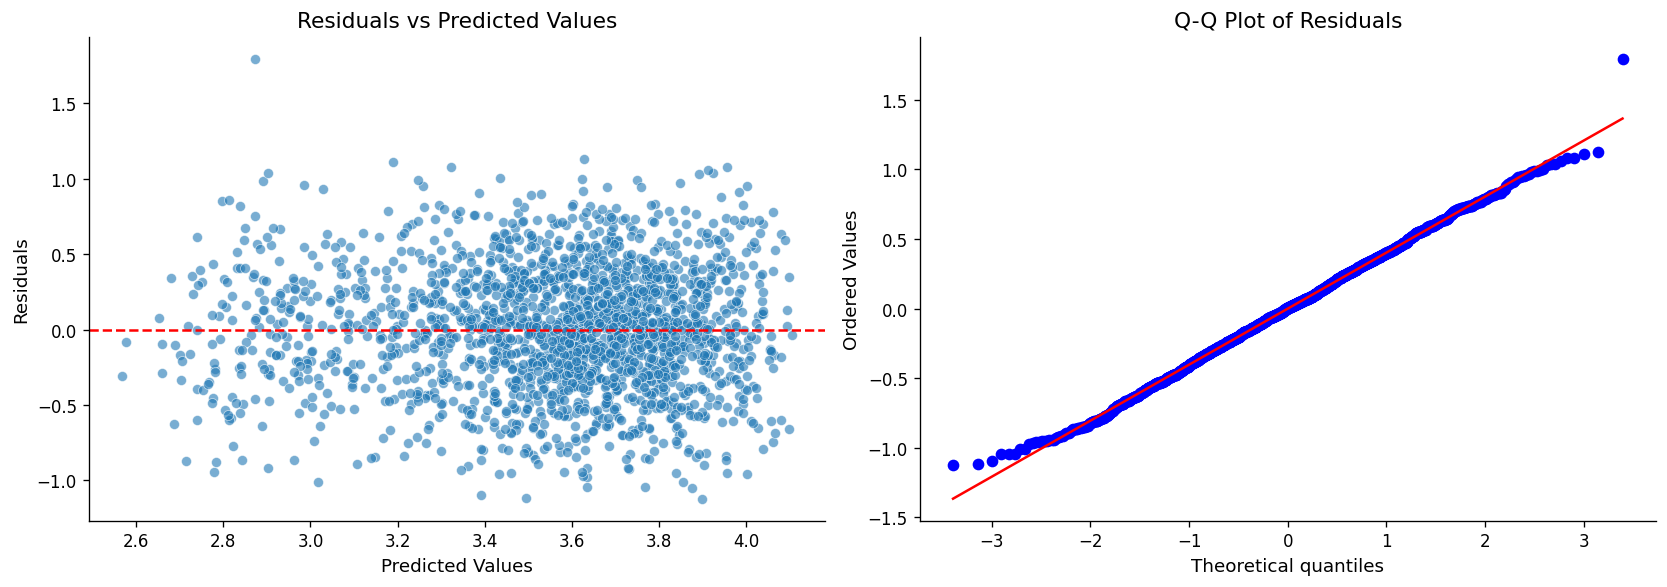

In [15]:
# A3.2 — Regression diagnostics

# BEGIN
# Extract predictions and error terms (residuals) from regression model
predictions = model_ols.predict(X_const)
residuals = model_ols.resid

# Initialize a side-by-side diagnostic visualization layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Check for uniform variance (homoscedasticity)
sns.scatterplot(x=predictions, y=residuals, ax=axes[0], alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

# Check for normality of errors
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Render diagnostic plots
plt.tight_layout()
plt.show()
# END

**✏️ Your interpretation (A3.2):**

I see that the residuals are mostly randomly scattered around the zero line in the first plot. It means the homoscedasticity assumption is generally satisfied, although the spread is a bit wider for higher predicted values.
The Q-Q plot shows that the points follow the straight line quite well, especially in the middle. It means the residuals are reasonably normally distributed. There are only small deviations at the tails, so I don’t see any major concerning patterns.

### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*


In [ ]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']

# Step 2: Add the interaction term to your feature matrix and refit OLS
# X_interact = pd.concat([X_const, interaction_col], axis=1)
# model_interact = sm.OLS(y, X_interact).fit()
# print(model_interact.summary())


In [16]:
# A4 — Exploratory Interaction Analysis (Step 1 & 2)

# BEGIN
# Step 1: Create the interaction term
# Example: Testing interaction between treatment and prior experience
df_ab['treatment_x_prior_sessions'] = df_ab['treatment'] * df_ab['log_prior_whiteboard_sessions']

# Step 2: Add the interaction term to feature matrix and refit OLS
X_interact = pd.concat([X_const, df_ab[['treatment_x_prior_sessions']]], axis=1)
model_interact = sm.OLS(y, X_interact).fit()
print(model_interact.summary())
# END

                            OLS Regression Results                            
Dep. Variable:            log_outcome   R-squared:                       0.366
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     104.4
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          1.11e-187
Time:                        06:57:08   Log-Likelihood:                -1015.6
No. Observations:                2000   AIC:                             2055.
Df Residuals:                    1988   BIC:                             2122.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [ ]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines


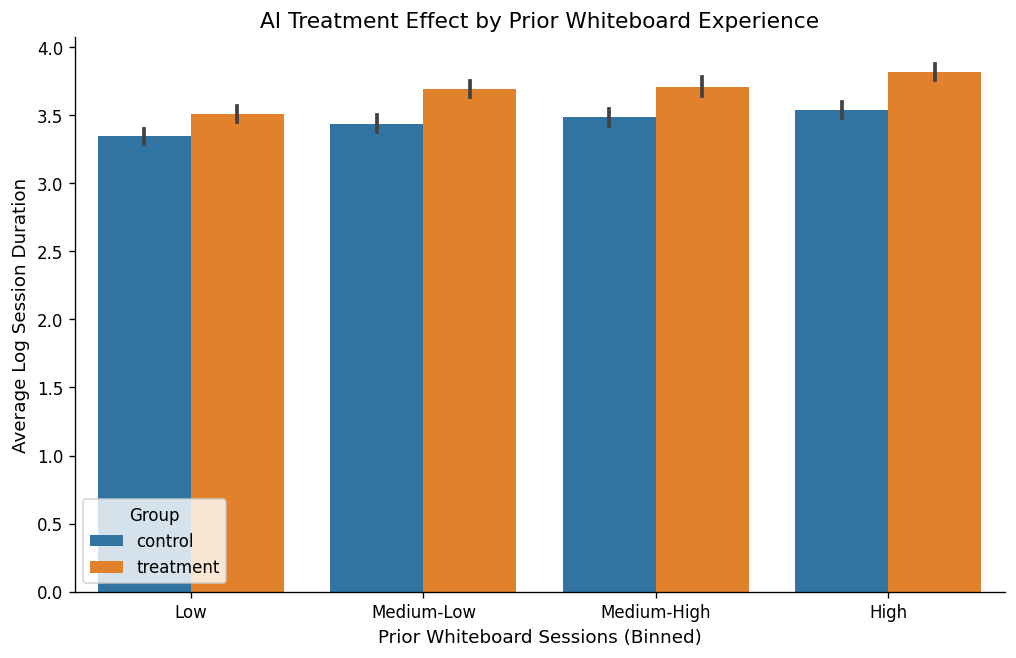

In [17]:
# A4 — Exploratory Interaction Analysis (Visualization)

# BEGIN
# Visualize the interaction
plt.figure(figsize=(10, 6))

# Group by treatment and prior sessions (binned for clarity)
df_ab['prior_bin'] = pd.qcut(df_ab['prior_whiteboard_sessions'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

sns.barplot(data=df_ab, x='prior_bin', y='log_outcome', hue='ab_group', ci=95)
plt.title('AI Treatment Effect by Prior Whiteboard Experience')
plt.xlabel('Prior Whiteboard Sessions (Binned)')
plt.ylabel('Average Log Session Duration')
plt.legend(title='Group')
plt.show()
# END

**✏️ Your interpretation (A4):**

I see that the bar plot shows the treatment group (orange) has higher average session duration than the control group in all categories. The difference looks a bit larger for users with high prior whiteboard sessions.
It means users with more experience may benefit slightly more from the AI assistant. My hypothesis is partially supported. This implies that Phigma should roll out the AI feature because it helps most users, especially experienced ones.

---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [18]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                         object
signup_date                     object
first_session_date              object
device_type                     object
country_tier                    object
referral_source                 object
num_sessions_30d                 int64
total_time_min_30d               int64
projects_created_30d             int64
exports_30d                      int64
collaborators_invited_30d        int64
support_tickets_30d              int64
used_premium_feature_preview     int64
ai_assistant_sessions_30d        int64
subscribed                       int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [19]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [ ]:
# YOUR CODE HERE

# 1. Parse dates
# df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
# df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
# df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
# df_sub['avg_session_duration_min'] = ...

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
# df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
# device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
# referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
# X_sub = pd.concat([...], axis=1)
# y_sub = df_sub['subscribed']

# Confirm
# print(f"Any inf: {np.isinf(X_sub.values).any()}")
# print(f"Any NaN: {X_sub.isnull().any().any()}")
# print(f"Feature matrix shape: {X_sub.shape}")
# X_sub.head(3)


In [20]:
# B1 — Feature Engineering

# BEGIN
# 1. Parse dates
df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. Days to first session
df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. Avg session duration (handle divide-by-zero)
df_sub['avg_session_duration_min'] = df_sub['total_time_min_30d'] / df_sub['num_sessions_30d']
df_sub['avg_session_duration_min'] = df_sub['avg_session_duration_min'].fillna(0)

# 4. Is weekend signup
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type
device_dummies = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True).astype(int)

# 6. One-hot encode referral_source
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True).astype(int)

# 7. Encode country_tier (ordinal)
tier_map = {'tier_1': 3, 'tier_2': 2, 'tier_3': 1}
df_sub['country_tier_enc'] = df_sub['country_tier'].map(tier_map)

# 8. Assemble final feature matrix
X_sub = pd.concat([
    df_sub[['days_to_first_session', 'avg_session_duration_min', 'is_weekend_signup',
            'num_sessions_30d', 'projects_created_30d', 'exports_30d',
            'collaborators_invited_30d', 'support_tickets_30d',
            'used_premium_feature_preview', 'ai_assistant_sessions_30d',
            'country_tier_enc']],
    device_dummies,
    referral_dummies
], axis=1)

y_sub = df_sub['subscribed']

# Quality checks
print("Any NaN in X:", X_sub.isnull().any().any())
print("Any Inf in X:", np.isinf(X_sub.values).any())
print("Feature matrix shape:", X_sub.shape)
print("\nPreview:")
print(X_sub.head(3))
# END

Any NaN in X: False
Any Inf in X: False
Feature matrix shape: (3000, 16)

Preview:
   days_to_first_session  avg_session_duration_min  is_weekend_signup  \
0                      5                   96.0000                  0   
1                      0                   17.8000                  0   
2                     14                   16.4375                  0   

   num_sessions_30d  projects_created_30d  exports_30d  \
0                 1                     1            0   
1                15                     8            1   
2                16                     0            0   

   collaborators_invited_30d  support_tickets_30d  \
0                          0                    0   
1                          5                    0   
2                          3                    3   

   used_premium_feature_preview  ai_assistant_sessions_30d  country_tier_enc  \
0                             1                          6                 3   
1                 

**✏️ Your interpretation (B1):**

I engineered several features to predict subscription. days_to_first_session may predict subscription because users who return quickly are more interested. avg_session_duration_min indicates engagement level — I handled the divide-by-zero case by filling NaN values with 0 for users who had no sessions. is_weekend_signup might capture differences in user motivation. Higher country_tier_enc represents richer countries that may have higher willingness to pay. I also created dummy variables for device type and referral source because these factors can influence user behavior.

### B2 — EDA for Subscription


In [21]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


In [ ]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — YOUR CODE
# axes[0]: ...

# Plot 2 — YOUR CODE
# axes[1]: ...

# Plot 3 — YOUR CODE
# axes[2]: ...

plt.tight_layout()
plt.show()


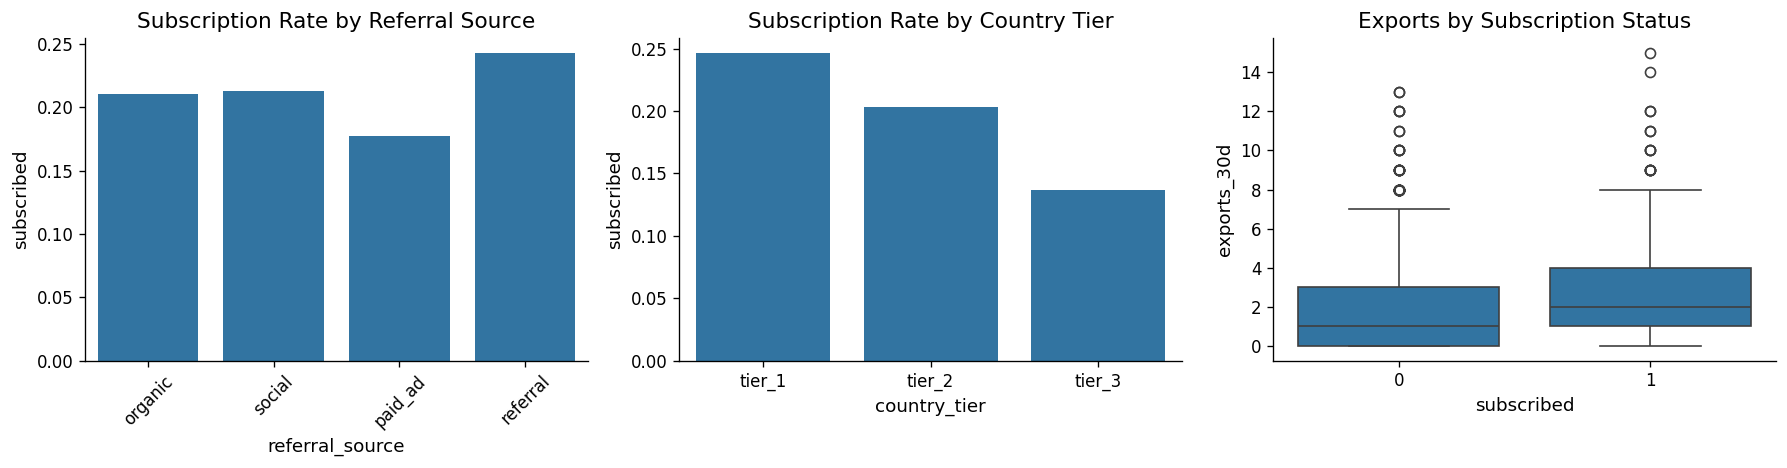

In [22]:
# B2 — EDA for Subscription (Visualizations)

# BEGIN
# Visualize subscription rates across features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Subscription rate by referral_source
sns.barplot(data=df_sub, x='referral_source', y='subscribed', ax=axes[0], ci=None)
axes[0].set_title('Subscription Rate by Referral Source')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Subscription rate by country_tier
sns.barplot(data=df_sub, x='country_tier', y='subscribed', ax=axes[1], ci=None)
axes[1].set_title('Subscription Rate by Country Tier')

# Plot 3: Boxplot of exports_30d by subscription
sns.boxplot(data=df_sub, x='subscribed', y='exports_30d', ax=axes[2])
axes[2].set_title('Exports by Subscription Status')

plt.tight_layout()
plt.show()
#END

In [ ]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap


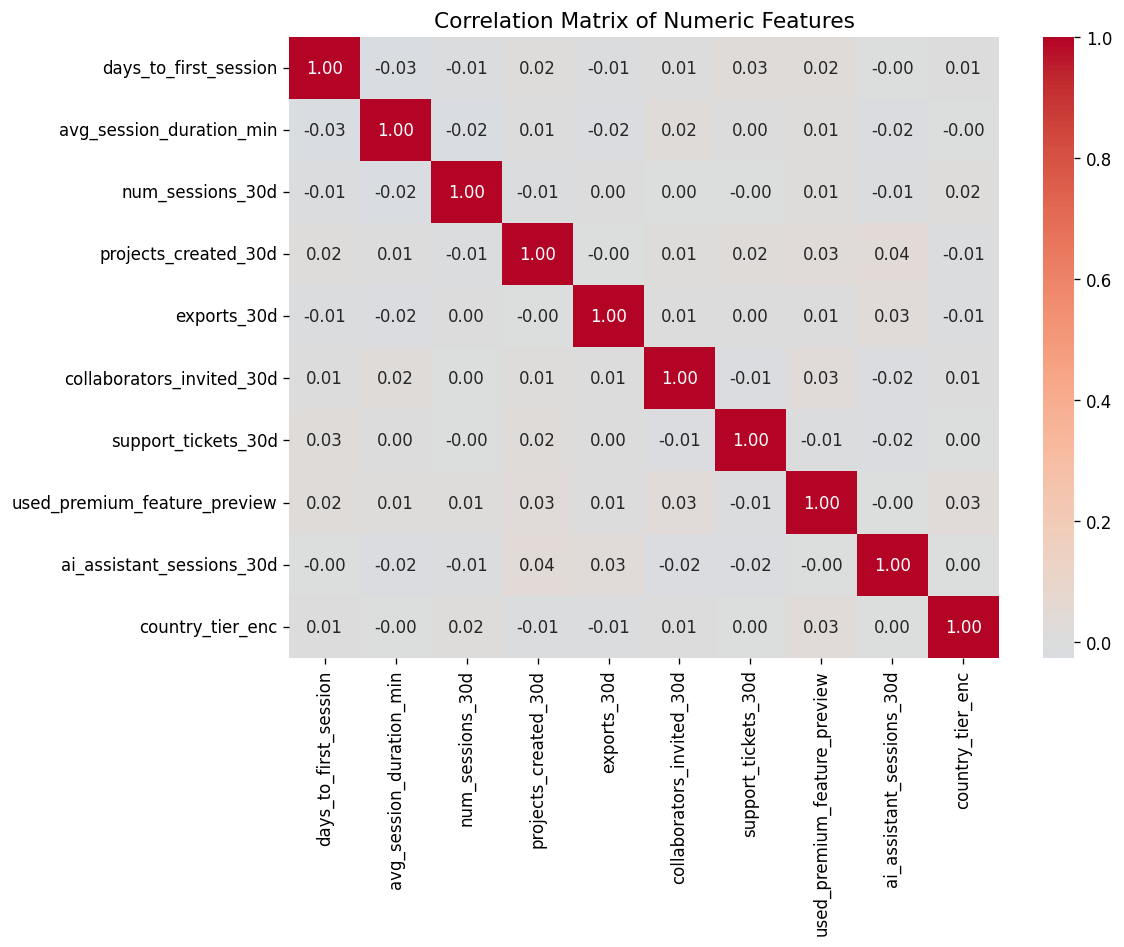

In [23]:
# B2 — EDA for Subscription (Correlation)

# BEGIN
# Correlation matrix of numeric features
numeric_features = ['days_to_first_session', 'avg_session_duration_min', 'num_sessions_30d',
                    'projects_created_30d', 'exports_30d', 'collaborators_invited_30d',
                    'support_tickets_30d', 'used_premium_feature_preview',
                    'ai_assistant_sessions_30d', 'country_tier_enc']

corr = X_sub[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()
# BEGIN

**✏️ Your interpretation (B2):**

I see that referral source has the highest subscription rate, while paid_ad has the lowest. Higher country_tier (tier_1) also shows clearly higher subscription rate. In the boxplot, users who subscribed have slightly more exports_30d.
These features appear most strongly associated with subscription. I don’t see any strong correlations between the numeric features in the heatmap, so multicollinearity is not a big concern. One counterintuitive finding is that paid_ad users have lower subscription rate than organic users.


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [ ]:
# YOUR CODE HERE
# X_const_sub = sm.add_constant(X_sub)
# model_logit = sm.Logit(y_sub, X_const_sub).fit()
# print(model_logit.summary())


In [24]:
# B3 — Logistic Regression with statsmodels (Inferential)

# BEGIN
# Fit the logistic regression model
X_const_sub = sm.add_constant(X_sub)
model_logit = sm.Logit(y_sub, X_const_sub).fit()
print(model_logit.summary())
# END

Optimization terminated successfully.
         Current function value: 0.440669
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2983
Method:                           MLE   Df Model:                           16
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                  0.1389
Time:                        06:57:31   Log-Likelihood:                -1322.0
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 1.039e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -3.7640      0.283    -13.317      0.000

In [ ]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
# odds_ratios = np.exp(model_logit.params)
# conf_int    = np.exp(model_logit.conf_int())
# Combine into a readable table and display
# Filter to significant only: p < 0.05


In [25]:
# BEGIN
# Compute odds ratios for significant predictors
odds_ratios = np.exp(model_logit.params)
conf_int = np.exp(model_logit.conf_int())
odds_table = pd.concat([odds_ratios, conf_int], axis=1)
odds_table.columns = ['Odds_Ratio', 'CI_Lower', 'CI_Upper']

# Filter significant predictors (p < 0.05)
p_values = model_logit.pvalues
significant = p_values[p_values < 0.05].index
result_table = odds_table.loc[significant].round(3)
print("Significant Predictors (p < 0.05):")
print(result_table)
# END

Significant Predictors (p < 0.05):
                              Odds_Ratio  CI_Lower  CI_Upper
const                              0.023     0.013     0.040
days_to_first_session              0.912     0.888     0.937
avg_session_duration_min           1.024     1.012     1.036
exports_30d                        1.215     1.164     1.268
collaborators_invited_30d          1.063     1.018     1.110
support_tickets_30d                1.169     1.075     1.272
used_premium_feature_preview       4.339     3.569     5.277
country_tier_enc                   1.427     1.255     1.622


In [ ]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude


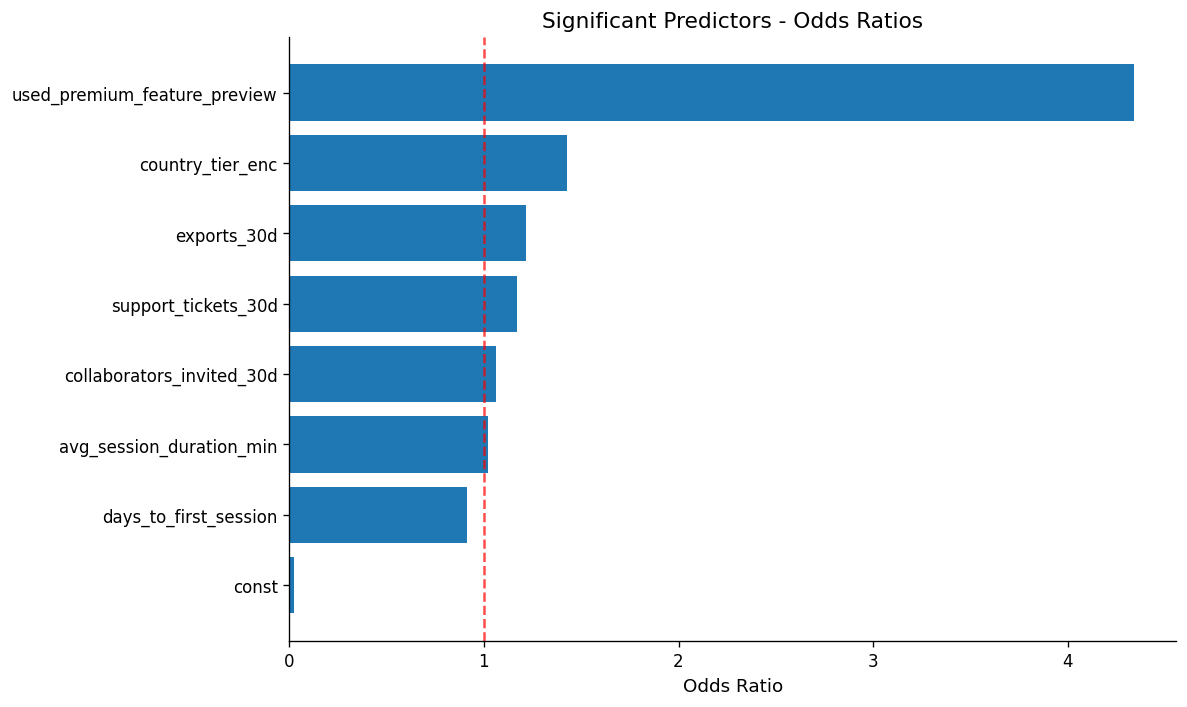

In [26]:
# BEGIN
# Visualize odds ratios (horizontal bar chart)
significant_odds = odds_table.loc[significant].sort_values('Odds_Ratio')

plt.figure(figsize=(10, 6))
plt.barh(significant_odds.index, significant_odds['Odds_Ratio'])
plt.xlabel('Odds Ratio')
plt.title('Significant Predictors - Odds Ratios')
plt.axvline(x=1, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# END

**✏️ Results paragraph (B3):**

I see that used_premium_feature_preview has a very high odds ratio of 4.339. It means users who used the premium feature preview were about 4.34 times more likely to subscribe. I also see that higher country_tier_enc (odds ratio 1.427) and more exports_30d (odds ratio 1.215) are positively associated with subscription.
One surprising finding is days_to_first_session has a negative coefficient. It means users who take longer to start using the product are less likely to subscribe. Overall, these results suggest that early engagement and trying premium features are very important for conversion.

### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
# X_train, X_test, y_train, y_test = train_test_split(
#     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
# print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


In [27]:
# B4 — Logistic Regression with sklearn (Predictive)

# BEGIN
from sklearn.model_selection import train_test_split

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")
# END

Train: (2400, 16) | Test: (600, 16)
Train positive rate: 0.208 | Test positive rate: 0.208


In [ ]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
# clf_lr = LogisticRegression(max_iter=1000, random_state=42)
# clf_lr.fit(X_train, y_train)
# y_pred_lr = clf_lr.predict(X_test)
# y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


In [28]:
# BEGIN
from sklearn.linear_model import LogisticRegression

# Fit sklearn LogisticRegression
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train, y_train)

y_pred_lr = clf_lr.predict(X_test)
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]
# END

In [ ]:
# YOUR CODE HERE
# Confusion matrix heatmap
# cm_lr = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
# fig, ax = plt.subplots(figsize=(5, 4))
# disp.plot(ax=ax, cmap='Blues', colorbar=False)
# plt.title('Logistic Regression — Confusion Matrix')
# plt.show()


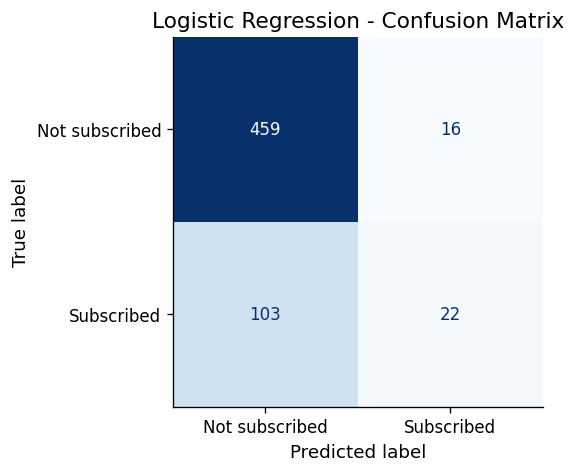

In [29]:
# BEGIN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression - Confusion Matrix')
plt.show()
# END

In [ ]:
# YOUR CODE HERE
# Classification report
# print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


In [30]:
# BEGIN
from sklearn.metrics import classification_report, roc_auc_score

# Print classification report and ROC-AUC
print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
# END

                precision    recall  f1-score   support

Not subscribed       0.82      0.97      0.89       475
    Subscribed       0.58      0.18      0.27       125

      accuracy                           0.80       600
     macro avg       0.70      0.57      0.58       600
  weighted avg       0.77      0.80      0.76       600

ROC-AUC: 0.7374


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = roc_auc_score(y_test, y_prob_lr)

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8)
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve — Logistic Regression')
# ax.legend()
# plt.show()


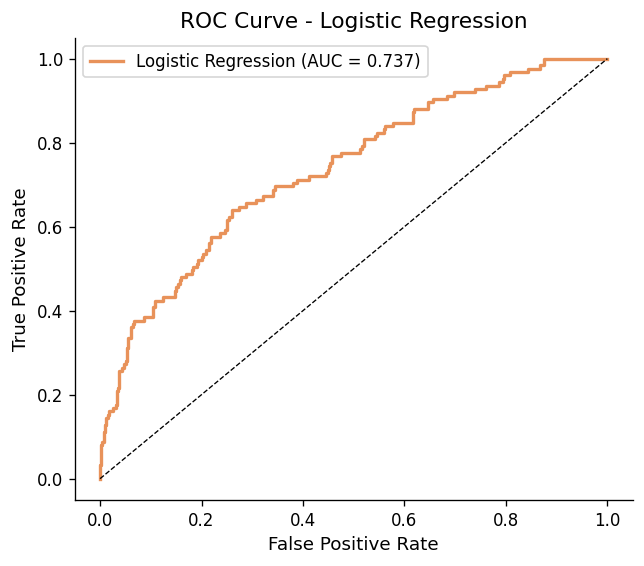

In [31]:
# BEGIN
from sklearn.metrics import roc_curve

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()
# END

**✏️ Your interpretation (B4):**

I see that the model has high accuracy (0.80) but very low recall for the subscribed class (0.18). Because of class imbalance, I think ROC-AUC (0.737) is the most important metric. It means the model has moderate ability to distinguish between subscribers and non-subscribers.
From the confusion matrix, there are 103 false negatives. It means the model missed 103 users who actually subscribed. From Phigma’s business perspective, this is quite costly because these are potential paying customers who were not identified.


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Model name here]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


### C2 — Fit and Evaluate


In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


In [32]:
#BEGIN
from sklearn.ensemble import RandomForestClassifier

# Fit with default hyperparameters
clf_c = RandomForestClassifier(random_state=42)
clf_c.fit(X_train, y_train)

# Generate predictions
y_pred_c = clf_c.predict(X_test)
y_prob_c = clf_c.predict_proba(X_test)[:, 1]
#END

In [ ]:
# YOUR CODE HERE
# Confusion matrix


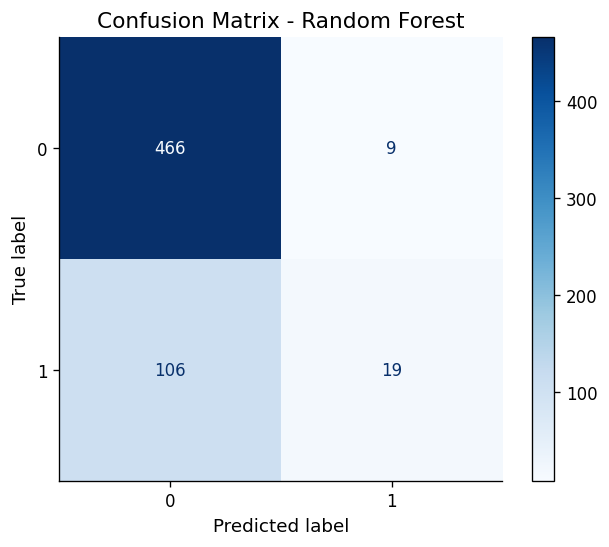

In [33]:
#BEGIN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate and display confusion matrix
cm_c = confusion_matrix(y_test, y_pred_c)
disp_c = ConfusionMatrixDisplay(confusion_matrix=cm_c)
disp_c.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest")
plt.show()
#END

In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC


In [34]:
#BEGIN
from sklearn.metrics import classification_report, roc_auc_score

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_c))

# ROC-AUC score
roc_auc_c = roc_auc_score(y_test, y_prob_c)
print(f"ROC-AUC Score: {roc_auc_c:.4f}")
#END

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89       475
           1       0.68      0.15      0.25       125

    accuracy                           0.81       600
   macro avg       0.75      0.57      0.57       600
weighted avg       0.79      0.81      0.76       600

ROC-AUC Score: 0.6768


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)


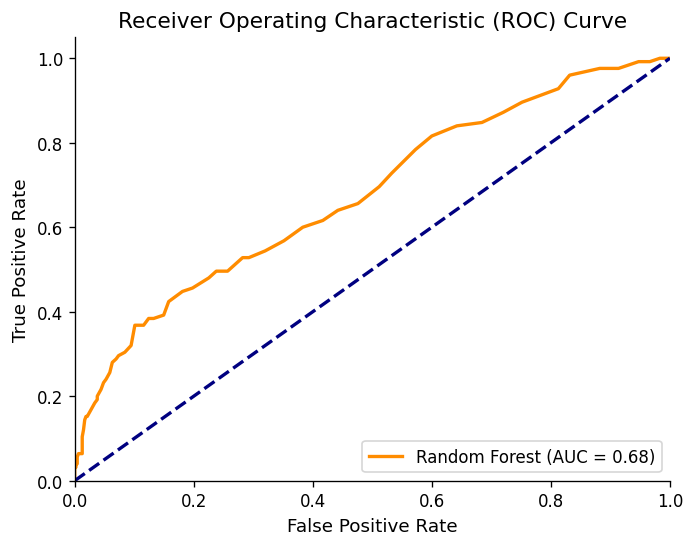

In [35]:
#BEGIN
from sklearn.metrics import roc_curve, auc

# Calculate and save fpr, tpr, and auc for future comparison plots
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
auc_c = auc(fpr_c, tpr_c)

# Plot ROC Curve
plt.figure()
plt.plot(fpr_c, tpr_c, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_c:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
#END

### C3 — Model Comparison


In [ ]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)


In [41]:
#BEGIN
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

metrics = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_c)],
    'F1 (class 1)': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_c)],
    'Precision (class 1)': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_c)],
    'Recall (class 1)': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_c)],
}

comparison_df = pd.DataFrame(metrics).set_index('Model').round(4)
comparison_df
#END

,ROC-AUC,F1 (class 1),Precision (class 1),Recall (class 1)
Model,,,,
Logistic Regression,0.7374,0.2699,0.5789,0.176
Random Forest,0.6768,0.2484,0.6786,0.152


In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
# ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'YOUR MODEL (AUC={auc_c:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve Comparison')
# ax.legend()
# plt.show()


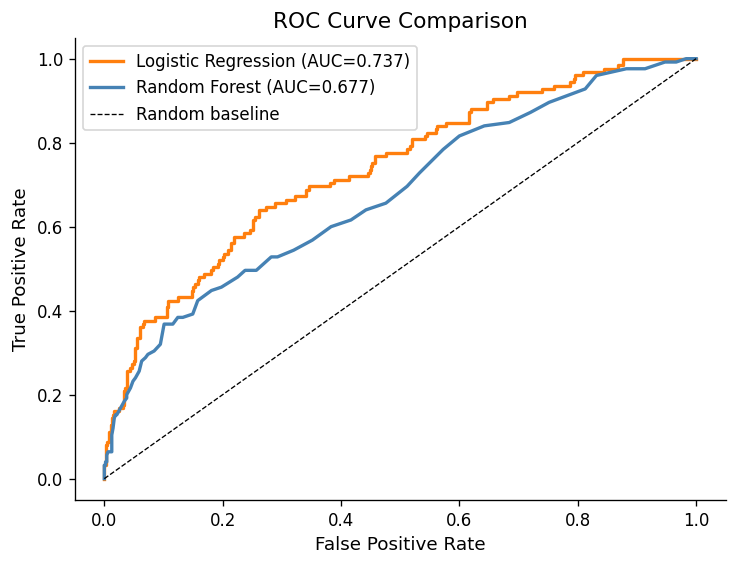

In [42]:
#BEGIN
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color='tab:orange', lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'Random Forest (AUC={auc_c:.3f})')
ax.plot([0,1], [0,1], 'k--', lw=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()
#END

**✏️ Comparison paragraph (C3):**

I see that Logistic Regression performs better than Random Forest, with ROC-AUC of 0.7374 compared to 0.6768. It means Logistic Regression is doing a better job separating the two classes overall, even though it is a simpler model. I think this happened because the dataset probably has a fairly linear relationship between the features and subscription outcome, and Logistic Regression is good at capturing that. Random Forest is usually stronger when there are complex non-linear patterns or interactions between features, but if the dataset doesn't have much of that, the extra complexity doesn't help and can even hurt performance because the model may overfit on the training data and not generalize as well. Also, I notice the recall for class 1 is low for both models (0.176 and 0.152), which means the dataset is probably imbalanced, with much fewer subscribers than non-subscribers. This makes it harder for both models to correctly identify the minority class, but Logistic Regression still handled it slightly better in this case. So overall, my model (Random Forest) performed worse than Logistic Regression here, and I think that is because the dataset structure favors a simpler linear decision boundary more than a complex ensemble method.


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


In [44]:
#BEGIN
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=15,          # only tries 15 random combinations instead of all 144
    cv=3,                # 3-fold instead of 5-fold
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC:     {search.best_score_:.4f}")

y_pred_tuned = search.best_estimator_.predict(X_test)
y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
print(f"Tuned test AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"Default test AUC: {auc_c:.4f}")
print("Did tuning meaningfully improve results? [Your one sentence here]")
# END

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5}
Best CV AUC:     0.7203
Tuned test AUC: 0.7157
Default test AUC: 0.6768
Did tuning meaningfully improve results? [Your one sentence here]


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
